# Evaluating Image-to-Image Translation under Domain Shift Using CNNs and GANs

## Overview
This project investigates how well deep learning models generalize under domain shift in an image-to-image translation task.

I compare:
- A CNN baseline model
- A conditional GAN model

Both models are trained to reconstruct images from edge maps. I then evaluate their performance on both standard data and shifted data (blurred inputs) to analyze robustness.

Key findings:
- CNN produces blurry, low-detail outputs
- GAN produces more structured and visually meaningful outputs
- GAN demonstrates greater robustness under domain shift

#1. Imports & Setup


In [ ]:
import torch
print(torch.cuda.is_available())
print(torch.cuda.get_device_name(0) if torch.cuda.is_available() else "No GPU")

In [ ]:
import os
import random
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

import torchvision
from torchvision import transforms
from torchvision.datasets import OxfordIIITPet

from PIL import Image

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

def resolve_project_dir():
    """Locate the repo root when running locally or from a notebook."""
    candidates = []

    if "__file__" in globals():
        candidates.append(Path(__file__).resolve().parent)

    candidates.append(Path.cwd().resolve())

    for start in candidates:
        for path in [start, *start.parents]:
            if (path / "requirements.txt").exists() and (path / "notebooks").exists():
                return path

    return Path.cwd().resolve()


project_dir = resolve_project_dir()
data_dir = project_dir / "data"
results_dir = project_dir / "results"
checkpoints_dir = project_dir / "checkpoints"

data_dir.mkdir(parents=True, exist_ok=True)
results_dir.mkdir(parents=True, exist_ok=True)
checkpoints_dir.mkdir(parents=True, exist_ok=True)

print("Project folder:", project_dir)
print("Data folder:", data_dir)
print("Results folder:", results_dir)
print("Checkpoints folder:", checkpoints_dir)

#2. Dataset Loading




## Dataset

I am using the Oxford-IIIT Pet dataset. Each image is resized to 128×128 and converted into an edge map using Canny edge detection. The model is trained to reconstruct the original image from its edge representation.

In [ ]:
data_path = str(data_dir)

transform = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.ToTensor(),
])

In [ ]:
transform = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.ToTensor(),
])

dataset = OxfordIIITPet(
    root=data_path,
    split="trainval",
    target_types="category",
    download=True,
    transform=transform
)

print("Dataset size:", len(dataset))

In [ ]:
dataloader = DataLoader(dataset, batch_size=16, shuffle=True)

batch = next(iter(dataloader))
images = batch[0]

plt.figure(figsize=(6, 6))
for i in range(6):
    plt.subplot(2, 3, i + 1)
    plt.imshow(images[i].permute(1, 2, 0))
    plt.axis("off")

plt.tight_layout()
plt.show()

#3. Edge-Map Generation

In [ ]:
import cv2

def get_edge_map(image_tensor):
    img = image_tensor.permute(1, 2, 0).numpy()

    gray = cv2.cvtColor((img * 255).astype(np.uint8), cv2.COLOR_RGB2GRAY)

    edges = cv2.Canny(gray, 100, 200)

    edges = edges / 255.0
    edges = np.stack([edges, edges, edges], axis=0)

    return torch.tensor(edges, dtype=torch.float32)

In [ ]:
sample_img = images[0]
edge_img = get_edge_map(sample_img)

plt.figure(figsize=(6,3))

plt.subplot(1,2,1)
plt.imshow(sample_img.permute(1,2,0))
plt.title("Original")
plt.axis('off')

plt.subplot(1,2,2)
plt.imshow(edge_img.permute(1,2,0), cmap='gray')
plt.title("Edge")
plt.axis('off')

plt.show()

In [ ]:
class EdgeToImageDataset(Dataset):
    def __init__(self, base_dataset):
        self.base_dataset = base_dataset

    def __len__(self):
        return len(self.base_dataset)

    def __getitem__(self, idx):
        img, _ = self.base_dataset[idx]
        edge = get_edge_map(img)
        return edge, img

In [ ]:
edge_dataset = EdgeToImageDataset(dataset)
print("Edge dataset size:", len(edge_dataset))

In [ ]:
edge_sample, img_sample = edge_dataset[0]

plt.figure(figsize=(6, 3))

plt.subplot(1, 2, 1)
plt.imshow(edge_sample.permute(1, 2, 0), cmap="gray")
plt.title("Edge Input")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(img_sample.permute(1, 2, 0))
plt.title("Target Image")
plt.axis("off")

plt.show()

In [ ]:
from torch.utils.data import Subset

train_size = 3000
test_size = 500

train_subset = Subset(edge_dataset, list(range(train_size)))
test_subset = Subset(edge_dataset, list(range(train_size, train_size + test_size)))

train_loader = DataLoader(train_subset, batch_size=16, shuffle=True)
test_loader = DataLoader(test_subset, batch_size=16, shuffle=False)

print("Train subset size:", len(train_subset))
print("Test subset size:", len(test_subset))

In [ ]:
edge_batch, img_batch = next(iter(train_loader))

plt.figure(figsize=(6, 4))
for i in range(2):
    plt.subplot(2, 2, 2*i + 1)
    plt.imshow(edge_batch[i].permute(1, 2, 0), cmap="gray")
    plt.title("Train Edge")
    plt.axis("off")

    plt.subplot(2, 2, 2*i + 2)
    plt.imshow(img_batch[i].permute(1, 2, 0))
    plt.title("Train Target")
    plt.axis("off")

plt.tight_layout()
plt.show()

#4. CNN Baseline

## CNN Baseline

I implement a simple encoder-decoder convolutional neural network that maps edge images to reconstructed outputs. The model is trained using L1 loss to minimize pixel-wise differences between predicted and target images.

In [ ]:
class SimpleCNN(nn.Module):
    def __init__(self):
        super(SimpleCNN, self).__init__()

        self.encoder = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=4, stride=2, padding=1),   # 128 -> 64
            nn.ReLU(inplace=True),

            nn.Conv2d(32, 64, kernel_size=4, stride=2, padding=1),  # 64 -> 32
            nn.ReLU(inplace=True),

            nn.Conv2d(64, 128, kernel_size=4, stride=2, padding=1), # 32 -> 16
            nn.ReLU(inplace=True)
        )

        self.decoder = nn.Sequential(
            nn.ConvTranspose2d(128, 64, kernel_size=4, stride=2, padding=1),  # 16 -> 32
            nn.ReLU(inplace=True),

            nn.ConvTranspose2d(64, 32, kernel_size=4, stride=2, padding=1),   # 32 -> 64
            nn.ReLU(inplace=True),

            nn.ConvTranspose2d(32, 3, kernel_size=4, stride=2, padding=1),    # 64 -> 128
            nn.Sigmoid()
        )

    def forward(self, x):
        x = self.encoder(x)
        x = self.decoder(x)
        return x

In [ ]:
cnn_model = SimpleCNN().to(device)
criterion = nn.L1Loss()
optimizer = torch.optim.Adam(cnn_model.parameters(), lr=0.001)

print(cnn_model)

In [ ]:
edge_batch, img_batch = next(iter(train_loader))
edge_batch = edge_batch.to(device)

with torch.no_grad():
    output_batch = cnn_model(edge_batch)

print("Input shape :", edge_batch.shape)
print("Output shape:", output_batch.shape)

In [ ]:
def train_cnn(model, train_loader, criterion, optimizer, device, epochs=3):
    model.train()
    train_losses = []

    for epoch in range(epochs):
        running_loss = 0.0

        for edges, targets in train_loader:
            edges = edges.to(device)
            targets = targets.to(device)

            optimizer.zero_grad()
            outputs = model(edges)
            loss = criterion(outputs, targets)
            loss.backward()
            optimizer.step()

            running_loss += loss.item()

        avg_loss = running_loss / len(train_loader)
        train_losses.append(avg_loss)
        print(f"Epoch [{epoch+1}/{epochs}] - Loss: {avg_loss:.4f}")

    return train_losses

In [ ]:
cnn_losses = train_cnn(
    cnn_model,
    train_loader,
    criterion,
    optimizer,
    device,
    epochs=10
)

In [ ]:
plt.figure(figsize=(5,3))
plt.plot(cnn_losses, marker='o')
plt.title("CNN Training Loss")
plt.xlabel("Epoch")
plt.ylabel("L1 Loss")
plt.show()

In [ ]:
cnn_model.eval()

edge_batch, target_batch = next(iter(test_loader))
edge_batch = edge_batch.to(device)

with torch.no_grad():
    output_batch = cnn_model(edge_batch)

edge_batch = edge_batch.cpu()
output_batch = output_batch.cpu()
target_batch = target_batch.cpu()

plt.figure(figsize=(8,6))

for i in range(3):
    # Edge
    plt.subplot(3,3,3*i+1)
    plt.imshow(edge_batch[i].permute(1,2,0), cmap="gray")
    plt.title("Edge")
    plt.axis("off")

    # CNN Output
    plt.subplot(3,3,3*i+2)
    plt.imshow(output_batch[i].permute(1,2,0))
    plt.title("CNN Output")
    plt.axis("off")

    # Ground Truth
    plt.subplot(3,3,3*i+3)
    plt.imshow(target_batch[i].permute(1,2,0))
    plt.title("Target")
    plt.axis("off")

plt.tight_layout()
plt.show()

#5. GAN Model

## GAN Model

I implement a conditional GAN consisting of:
- A generator that maps edge images to reconstructed images
- A discriminator that distinguishes between real and generated images

The generator is trained using a combination of adversarial loss and L1 reconstruction loss.

In [ ]:
class Generator(nn.Module):
    def __init__(self):
        super(Generator, self).__init__()

        self.model = nn.Sequential(
            nn.Conv2d(3, 64, kernel_size=4, stride=2, padding=1),   # 128 -> 64
            nn.ReLU(inplace=True),

            nn.Conv2d(64, 128, kernel_size=4, stride=2, padding=1), # 64 -> 32
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),

            nn.Conv2d(128, 256, kernel_size=4, stride=2, padding=1), # 32 -> 16
            nn.BatchNorm2d(256),
            nn.ReLU(inplace=True),

            nn.ConvTranspose2d(256, 128, kernel_size=4, stride=2, padding=1), # 16 -> 32
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),

            nn.ConvTranspose2d(128, 64, kernel_size=4, stride=2, padding=1),  # 32 -> 64
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),

            nn.ConvTranspose2d(64, 3, kernel_size=4, stride=2, padding=1),    # 64 -> 128
            nn.Sigmoid()
        )

    def forward(self, x):
        return self.model(x)

In [ ]:
class Discriminator(nn.Module):
    def __init__(self):
        super(Discriminator, self).__init__()

        self.model = nn.Sequential(
            nn.Conv2d(6, 64, kernel_size=4, stride=2, padding=1),   # edge + image = 6 channels
            nn.LeakyReLU(0.2, inplace=True),

            nn.Conv2d(64, 128, kernel_size=4, stride=2, padding=1),
            nn.BatchNorm2d(128),
            nn.LeakyReLU(0.2, inplace=True),

            nn.Conv2d(128, 256, kernel_size=4, stride=2, padding=1),
            nn.BatchNorm2d(256),
            nn.LeakyReLU(0.2, inplace=True),

            nn.Conv2d(256, 1, kernel_size=16),  # collapse to single prediction
            nn.Sigmoid()
        )

    def forward(self, edge, img):
        x = torch.cat([edge, img], dim=1)
        return self.model(x)

In [ ]:
generator = Generator().to(device)
discriminator = Discriminator().to(device)

edge_batch, img_batch = next(iter(train_loader))
edge_batch = edge_batch.to(device)
img_batch = img_batch.to(device)

with torch.no_grad():
    fake_imgs = generator(edge_batch)
    disc_out = discriminator(edge_batch, fake_imgs)

print("Edge batch shape:       ", edge_batch.shape)
print("Fake image shape:       ", fake_imgs.shape)
print("Discriminator out shape:", disc_out.shape)


In [ ]:
adversarial_loss = nn.BCELoss()
reconstruction_loss = nn.L1Loss()

g_optimizer = torch.optim.Adam(generator.parameters(), lr=0.0002, betas=(0.5, 0.999))
d_optimizer = torch.optim.Adam(discriminator.parameters(), lr=0.0002, betas=(0.5, 0.999))

In [ ]:
real_labels = torch.ones((16, 1, 1, 1), device=device)
fake_labels = torch.zeros((16, 1, 1, 1), device=device)

print("Real labels shape:", real_labels.shape)
print("Fake labels shape:", fake_labels.shape)

In [ ]:
def train_gan(generator, discriminator, train_loader, adversarial_loss, reconstruction_loss,
              g_optimizer, d_optimizer, device, epochs=3, lambda_l1=100):

    g_losses = []
    d_losses = []

    for epoch in range(epochs):
        generator.train()
        discriminator.train()

        running_g_loss = 0.0
        running_d_loss = 0.0

        for edges, real_imgs in train_loader:
            edges = edges.to(device)
            real_imgs = real_imgs.to(device)

            batch_size = edges.size(0)
            real_labels = torch.ones((batch_size, 1, 1, 1), device=device)
            fake_labels = torch.zeros((batch_size, 1, 1, 1), device=device)

            # -----------------
            # Train Discriminator
            # -----------------
            d_optimizer.zero_grad()

            fake_imgs = generator(edges).detach()

            real_preds = discriminator(edges, real_imgs)
            fake_preds = discriminator(edges, fake_imgs)

            d_real_loss = adversarial_loss(real_preds, real_labels)
            d_fake_loss = adversarial_loss(fake_preds, fake_labels)
            d_loss = (d_real_loss + d_fake_loss) / 2

            d_loss.backward()
            d_optimizer.step()

            # -----------------
            # Train Generator
            # -----------------
            g_optimizer.zero_grad()

            fake_imgs = generator(edges)
            fake_preds = discriminator(edges, fake_imgs)

            g_adv_loss = adversarial_loss(fake_preds, real_labels)
            g_l1_loss = reconstruction_loss(fake_imgs, real_imgs)
            g_loss = g_adv_loss + lambda_l1 * g_l1_loss

            g_loss.backward()
            g_optimizer.step()

            running_d_loss += d_loss.item()
            running_g_loss += g_loss.item()

        avg_d_loss = running_d_loss / len(train_loader)
        avg_g_loss = running_g_loss / len(train_loader)

        d_losses.append(avg_d_loss)
        g_losses.append(avg_g_loss)

        print(f"Epoch [{epoch+1}/{epochs}] - D Loss: {avg_d_loss:.4f} | G Loss: {avg_g_loss:.4f}")

    return g_losses, d_losses

In [ ]:
g_losses, d_losses = train_gan(
    generator,
    discriminator,
    train_loader,
    adversarial_loss,
    reconstruction_loss,
    g_optimizer,
    d_optimizer,
    device,
    epochs=8,
    lambda_l1=100
)

In [ ]:
plt.figure(figsize=(6,3))
plt.plot(g_losses, marker='o', label='Generator Loss')
plt.plot(d_losses, marker='o', label='Discriminator Loss')
plt.title("GAN Training Losses")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()

In [ ]:
generator.eval()

edge_batch, target_batch = next(iter(test_loader))
edge_batch = edge_batch.to(device)

with torch.no_grad():
    gan_output_batch = generator(edge_batch)

edge_batch = edge_batch.cpu()
gan_output_batch = gan_output_batch.cpu()
target_batch = target_batch.cpu()

plt.figure(figsize=(8, 6))

for i in range(3):
    plt.subplot(3, 3, 3*i + 1)
    plt.imshow(edge_batch[i].permute(1, 2, 0), cmap="gray")
    plt.title("Edge")
    plt.axis("off")

    plt.subplot(3, 3, 3*i + 2)
    plt.imshow(gan_output_batch[i].permute(1, 2, 0))
    plt.title("GAN Output")
    plt.axis("off")

    plt.subplot(3, 3, 3*i + 3)
    plt.imshow(target_batch[i].permute(1, 2, 0))
    plt.title("Target")
    plt.axis("off")

plt.tight_layout()
plt.show()

In [ ]:
cnn_model.eval()
generator.eval()

edge_batch, target_batch = next(iter(test_loader))
edge_batch_device = edge_batch.to(device)

with torch.no_grad():
    cnn_output_batch = cnn_model(edge_batch_device).cpu()
    gan_output_batch = generator(edge_batch_device).cpu()

target_batch = target_batch.cpu()

plt.figure(figsize=(10, 8))

for i in range(3):
    plt.subplot(3, 4, 4*i + 1)
    plt.imshow(edge_batch[i].permute(1, 2, 0), cmap="gray")
    plt.title("Edge")
    plt.axis("off")

    plt.subplot(3, 4, 4*i + 2)
    plt.imshow(cnn_output_batch[i].permute(1, 2, 0))
    plt.title("CNN")
    plt.axis("off")

    plt.subplot(3, 4, 4*i + 3)
    plt.imshow(gan_output_batch[i].permute(1, 2, 0))
    plt.title("GAN")
    plt.axis("off")

    plt.subplot(3, 4, 4*i + 4)
    plt.imshow(target_batch[i].permute(1, 2, 0))
    plt.title("Target")
    plt.axis("off")

plt.tight_layout()
plt.show()

# 6.Domain Shift Testing




## Domain Shift

To evaluate robustness, I introduce a domain shift by applying Gaussian blur before edge detection. This reduces high-frequency detail and simulates a change in input distribution.

In [ ]:
def get_blurred_edge_map(image_tensor):
    img = image_tensor.permute(1, 2, 0).numpy()
    img_uint8 = (img * 255).astype(np.uint8)

    # Apply Gaussian blur
    blurred = cv2.GaussianBlur(img_uint8, (9, 9), 0)

    # Convert to grayscale
    gray = cv2.cvtColor(blurred, cv2.COLOR_RGB2GRAY)

    # Edge detection
    edges = cv2.Canny(gray, 100, 200)

    edges = edges / 255.0
    edges = np.stack([edges, edges, edges], axis=0)

    return torch.tensor(edges, dtype=torch.float32)

In [ ]:
class BlurredEdgeToImageDataset(Dataset):
    def __init__(self, base_dataset):
        self.base_dataset = base_dataset

    def __len__(self):
        return len(self.base_dataset)

    def __getitem__(self, idx):
        img, _ = self.base_dataset[idx]
        edge = get_blurred_edge_map(img)
        return edge, img

In [ ]:
shifted_dataset = BlurredEdgeToImageDataset(dataset)
shifted_test_subset = Subset(shifted_dataset, list(range(train_size, train_size + test_size)))
shifted_test_loader = DataLoader(shifted_test_subset, batch_size=16, shuffle=False)

print("Shifted test subset size:", len(shifted_test_subset))

In [ ]:
shifted_edges, shifted_targets = next(iter(shifted_test_loader))

plt.figure(figsize=(6, 4))
for i in range(2):
    plt.subplot(2, 2, 2*i + 1)
    plt.imshow(shifted_edges[i].permute(1, 2, 0), cmap="gray")
    plt.title("Shifted Edge")
    plt.axis("off")

    plt.subplot(2, 2, 2*i + 2)
    plt.imshow(shifted_targets[i].permute(1, 2, 0))
    plt.title("Target")
    plt.axis("off")

plt.tight_layout()
plt.show()

In [ ]:
cnn_model.eval()
generator.eval()

edge_batch, target_batch = next(iter(shifted_test_loader))
edge_batch_device = edge_batch.to(device)

with torch.no_grad():
    cnn_output_batch = cnn_model(edge_batch_device).cpu()
    gan_output_batch = generator(edge_batch_device).cpu()

target_batch = target_batch.cpu()

plt.figure(figsize=(10, 8))

for i in range(3):
    plt.subplot(3, 4, 4*i + 1)
    plt.imshow(edge_batch[i].permute(1, 2, 0), cmap="gray")
    plt.title("Shifted Edge")
    plt.axis("off")

    plt.subplot(3, 4, 4*i + 2)
    plt.imshow(cnn_output_batch[i].permute(1, 2, 0))
    plt.title("CNN")
    plt.axis("off")

    plt.subplot(3, 4, 4*i + 3)
    plt.imshow(gan_output_batch[i].permute(1, 2, 0))
    plt.title("GAN")
    plt.axis("off")

    plt.subplot(3, 4, 4*i + 4)
    plt.imshow(target_batch[i].permute(1, 2, 0))
    plt.title("Target")
    plt.axis("off")

plt.tight_layout()
plt.show()

#7. Visual Results

## Results

I compare the CNN and GAN models on both standard and shifted inputs using visual inspection and L1 loss.

Figure 1 - CNN Training Loss

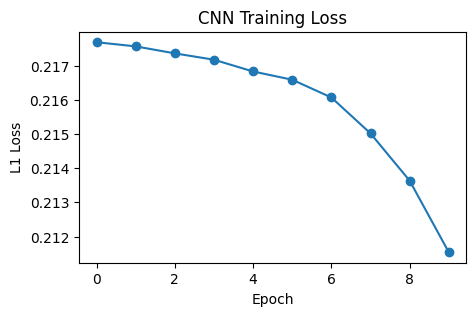

Figure 2 - GAN Training Loss

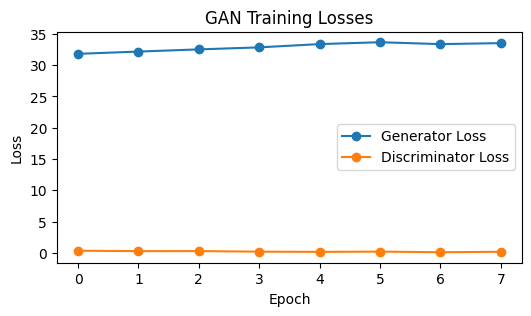

Figure 3 - CNN vs GAN (Normal Data)

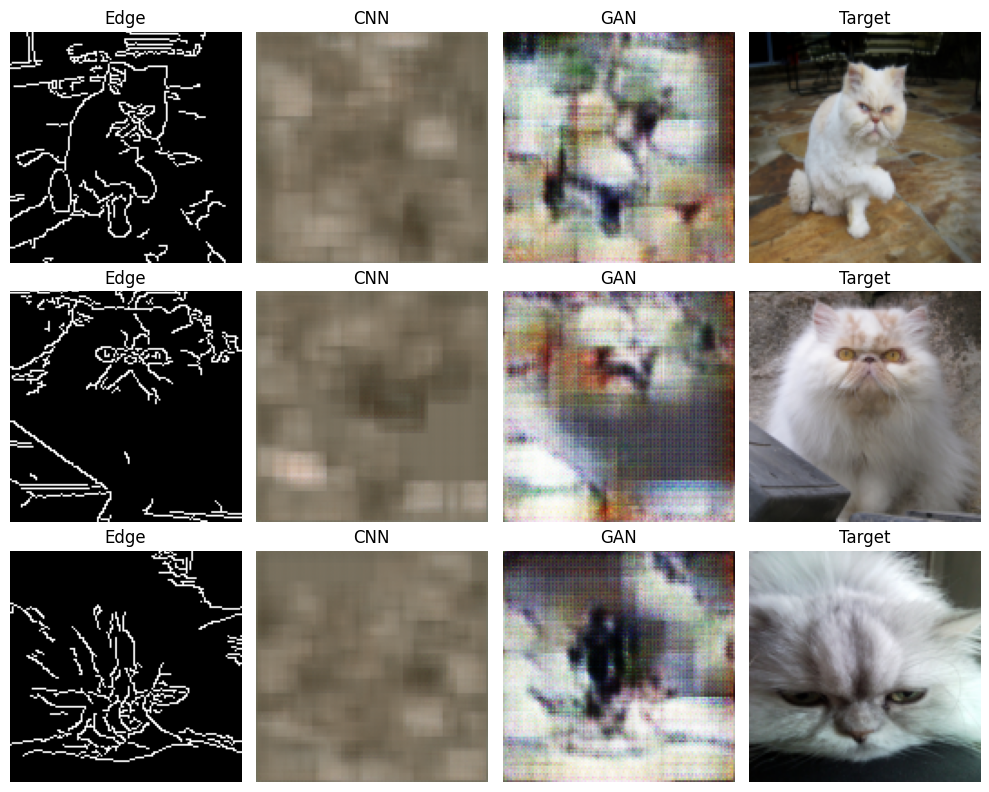

Figure 4 - CNN vs GAN under Domain Shift

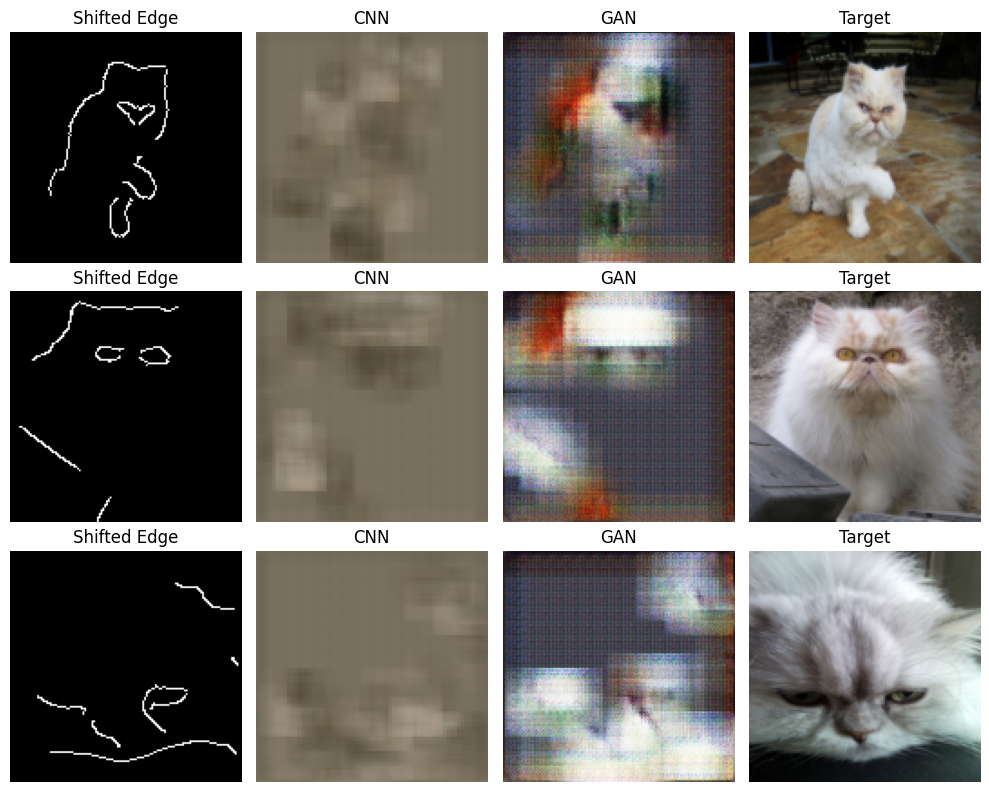

#8. Metrics & Comparison

In [ ]:
def evaluate_l1(model, dataloader, device):
    model.eval()
    total_loss = 0.0
    count = 0
    criterion = nn.L1Loss()

    with torch.no_grad():
        for edges, targets in dataloader:
            edges = edges.to(device)
            targets = targets.to(device)

            outputs = model(edges)
            loss = criterion(outputs, targets)

            total_loss += loss.item()
            count += 1

    return total_loss / count

In [ ]:
cnn_l1 = evaluate_l1(cnn_model, test_loader, device)
gan_l1 = evaluate_l1(generator, test_loader, device)

print("CNN L1 Loss:", cnn_l1)
print("GAN L1 Loss:", gan_l1)

In [ ]:
# Save the final weights
cnn_checkpoint_path = checkpoints_dir / "cnn_best.pth"
gan_checkpoint_path = checkpoints_dir / "gan_best.pth"

torch.save(cnn_model.state_dict(), cnn_checkpoint_path)
torch.save(generator.state_dict(), gan_checkpoint_path)

print(f"Weights saved successfully to {checkpoints_dir}")

## Conclusion

The CNN baseline struggles to reconstruct meaningful images and produces blurry outputs. The GAN generates more structured and visually rich results, even under domain shift.

Although the CNN achieves lower L1 loss, its outputs are less perceptually meaningful. This highlights a limitation of pixel-wise metrics, which may favor blurry reconstructions over realistic ones.

Overall, the GAN demonstrates greater robustness and is better suited for image-to-image translation tasks under domain shift.